In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
 
path="Position_Salaries.csv"
dataset = pd.read_csv(path)
 
# Independent variable (Position Level)
X = dataset.iloc[:, 1:-1].values
 
# Dependent variable (Salary)
y = dataset.iloc[:, -1].values
 
# Display dataset preview
print("Dataset Preview:")
print(dataset.head())
 
 

Dataset Preview:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [3]:
# Training the Linear Regression model on the whole dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
 
# Training the Polynomial Regression model on the whole dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)
 
print("✅ Models Trained Successfully!")

✅ Models Trained Successfully!


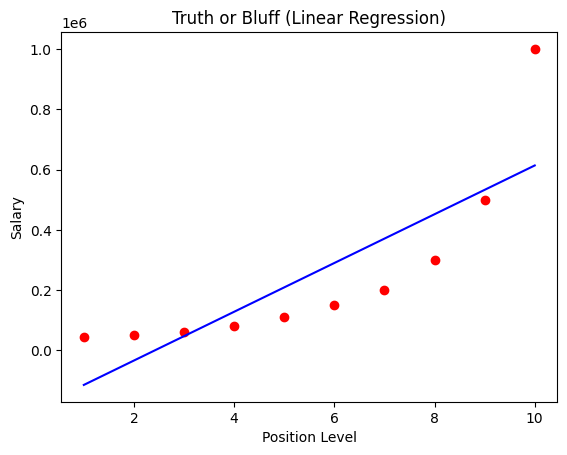

In [4]:
# Visualising the Linear Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()
 

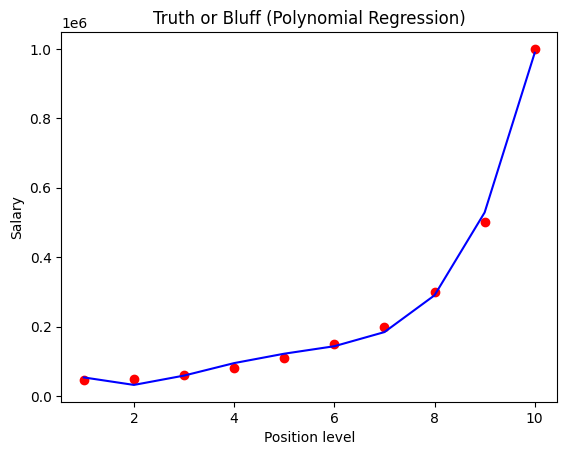

In [5]:
# Visualising the Polynomial Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

C:\Users\Raghunandan\AppData\Local\Temp\ipykernel_16196\2018302809.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


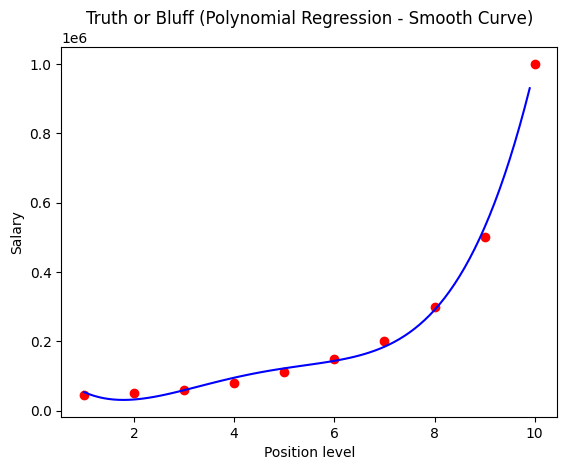

In [6]:
# Visualising the Polynomial Regression results (for higher resolution and smoother curve)
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression - Smooth Curve)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()
 

In [7]:
# Predicting a new result with Linear Regression
linear_prediction = lin_reg.predict([[6.5]])
print("Linear Regression Prediction for Level 6.5:", linear_prediction)

Linear Regression Prediction for Level 6.5: [330378.78787879]


In [8]:
# Predicting a new result with Polynomial Regression
poly_prediction = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print("Polynomial Regression Prediction for Level 6.5:", poly_prediction)

Polynomial Regression Prediction for Level 6.5: [158862.45265155]


In [9]:
df=pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [66]:
x=df[['enginesize']]
y_car=df['price']
x_sorted=np.sort(x.values,axis=0)

In [53]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x, y_car)
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 3)
X_poly = poly_reg.fit_transform(x)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y_car)
print("✅ Models Trained Successfully!")

✅ Models Trained Successfully!


C:\Users\Raghunandan\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


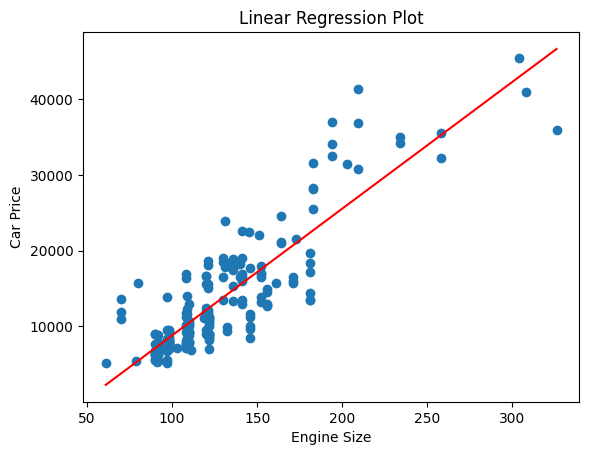

In [54]:
plt.xlabel('Engine Size')
plt.ylabel('Car Price')
plt.title("Linear Regression Plot")
plt.scatter(x,y_car)
plt.plot(x_sorted,lin_reg.predict(x_sorted),color='red')

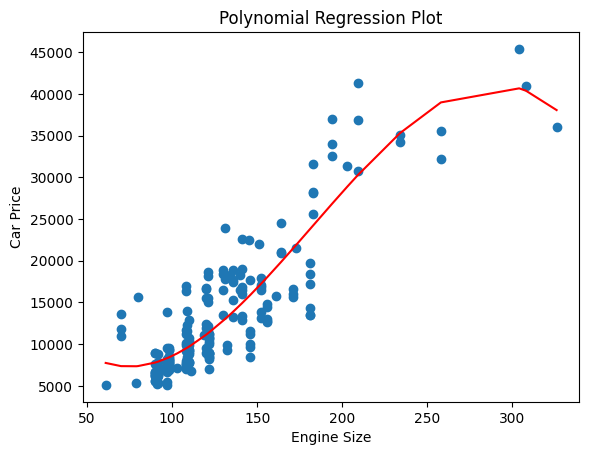

In [41]:
plt.xlabel('Engine Size')
plt.ylabel('Car Price')
plt.title("Polynomial Regression Plot")
plt.scatter(x,y_car)
plt.plot(x_sorted,lin_reg_2.predict(poly_reg.fit_transform(x_sorted)),color='red')

In [55]:
price_predict=lin_reg_2.predict(poly_reg.fit_transform([[200]]))
print('Car price when engine size is 200 with polynomial regression : ',price_predict)

Car price when engine size is 200 with polynomial regression :  [28207.45163671]


In [56]:
price_predict_l=lin_reg.predict([[200]])
print('Car price when engine size is 200 with linear regression : ',price_predict_l)

Car price when engine size is 200 with linear regression :  [25534.23774749]


C:\Users\Raghunandan\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
X=df[['enginesize']]
Y=df['price']
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)
model_l=LinearRegression()
model_l.fit(x_train,y_train)
y_pred=model_l.predict(x_test)
print("R2 Score : ",r2_score(y_test,y_pred))

R2 Score :  0.7534902447506853


In [72]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

<Axes: >

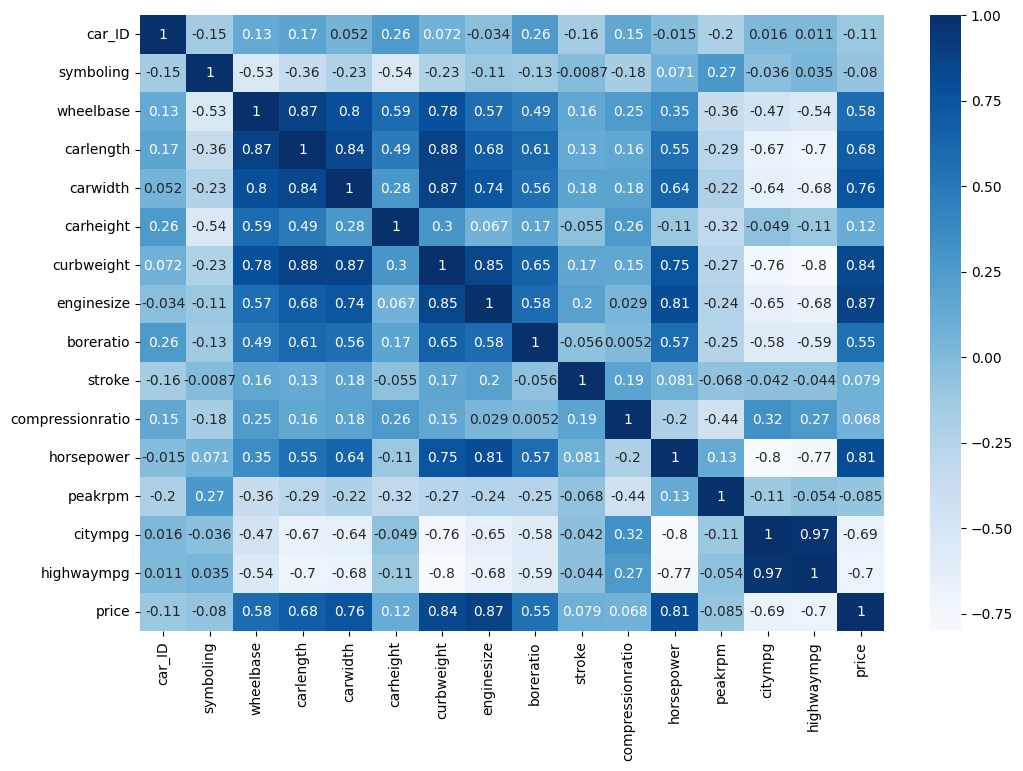

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
corr_m=df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_m,annot=True,cmap='Blues')

In [102]:
#Positive Correlation (wheel base,car length,car width,car height,curb weight,engine size,bore ratio,stroke,compression ratio,horse power)
#Negative Correlation (car id,symboling,peak rpm,city mpg,highway mpg)
target='price'
for i in corr_m.columns:
    if i!=target:
        value=corr_m[target][i]
        if(0.3<=value<=0.7):
            print(f"{i} is moderate positive correlation with value {value}")
        elif(0<value<0.3):
            print(f"{i} is weak positive correaltion with value {value}")
        elif(value>0.7):
            print(f"{i} is strong positive correaltion with value {value}")
        elif(-0.7<=value<=-0.3):
            print(f"{i} is moderate negative correlation with value {value}")
        elif(-0.3<value<0):
            print(f"{i} is weak negative correlation with value {value}")
        elif(value<-0.7):
            print(f"{i} is strong negative correlation with value {value}")

car_ID is weak negative correlation with value -0.10909333948229938
symboling is weak negative correlation with value -0.07997822464270359
wheelbase is moderate positive correlation with value 0.5778155982921489
carlength is moderate positive correlation with value 0.6829200156779629
carwidth is strong positive correaltion with value 0.759325299741511
carheight is weak positive correaltion with value 0.11933622657049496
curbweight is strong positive correaltion with value 0.8353048793372975
enginesize is strong positive correaltion with value 0.8741448025245117
boreratio is moderate positive correlation with value 0.5531732367984439
stroke is weak positive correaltion with value 0.0794430838819307
compressionratio is weak positive correaltion with value 0.06798350579944266
horsepower is strong positive correaltion with value 0.8081388225362214
peakrpm is weak negative correlation with value -0.0852671502778575
citympg is moderate negative correlation with value -0.68575133602704
highwa

<Axes: >

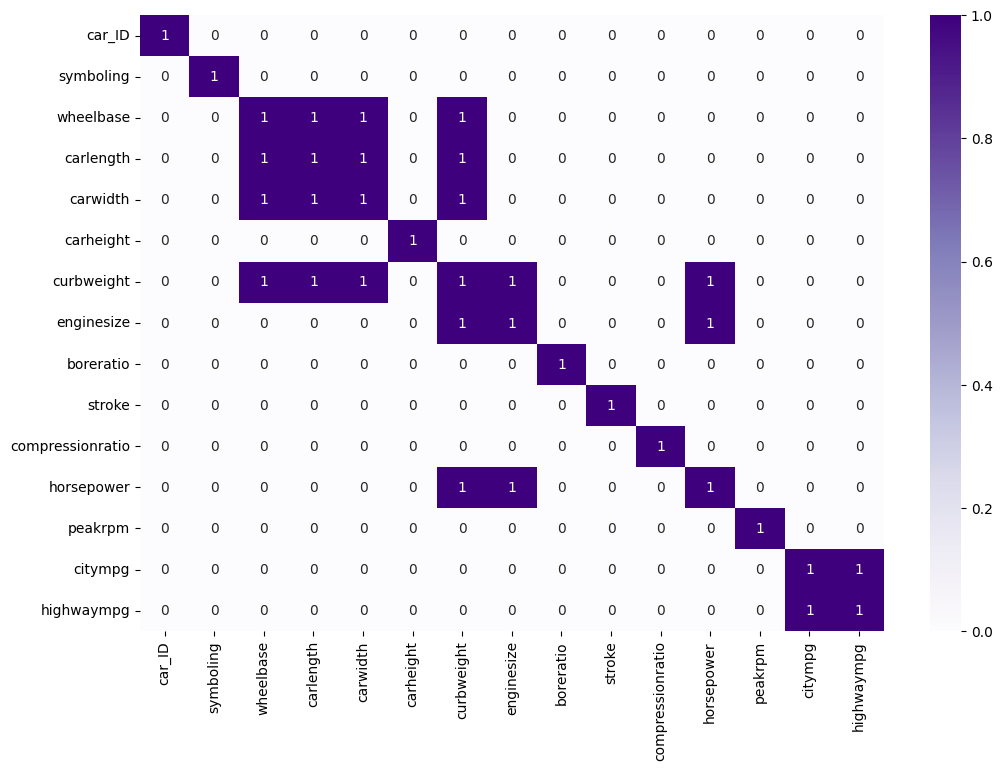

In [116]:
#Near to Zero (symboling,compression ratio,stroke,peak rpm)
X=df.drop('price',axis=1)
plt.figure(figsize=(12,8))
x_corr=X.corr(numeric_only=True)
sns.heatmap(x_corr>0.75,annot=True,cmap='Purples')

In [139]:
for i in x_corr:
    print(x_corr[i]==1)

car_ID               True
symboling           False
wheelbase           False
carlength           False
carwidth            False
carheight           False
curbweight          False
enginesize          False
boreratio           False
stroke              False
compressionratio    False
horsepower          False
peakrpm             False
citympg             False
highwaympg          False
Name: car_ID, dtype: bool
car_ID              False
symboling            True
wheelbase           False
carlength           False
carwidth            False
carheight           False
curbweight          False
enginesize          False
boreratio           False
stroke              False
compressionratio    False
horsepower          False
peakrpm             False
citympg             False
highwaympg          False
Name: symboling, dtype: bool
car_ID              False
symboling           False
wheelbase            True
carlength           False
carwidth            False
carheight           False
curbweigh

### Feature - Feature Realtionship > 0.75
1. wheelbase - carlength
2. wheelbase - carwidth
3. wheelbase - curbweight
4. carlength - carwidth
5. carlength - curbweight
6. carwidth - curbweight
7. curbweight - enginesize
8. curbweight - horsepower
9. enginesize - horsepower
10. citympg - highwaympg

In [ ]:
c=['symboling','peakrpm','stroke','compressionratio']
df.drop(columns=c)

,car_ID,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,horsepower,citympg,highwaympg,price
0,1,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,2548,dohc,four,130,mpfi,3.47,111,21,27,13495.0
1,2,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,2548,dohc,four,130,mpfi,3.47,111,21,27,16500.0
2,3,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,2823,ohcv,six,152,mpfi,2.68,154,19,26,16500.0
3,4,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,2337,ohc,four,109,mpfi,3.19,102,24,30,13950.0
4,5,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,2824,ohc,five,136,mpfi,3.19,115,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,...,2952,ohc,four,141,mpfi,3.78,114,23,28,16845.0
201,202,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,3049,ohc,four,141,mpfi,3.78,160,19,25,19045.0
202,203,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,...,3012,ohcv,six,173,mpfi,3.58,134,18,23,21485.0
203,204,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,3217,ohc,six,145,idi,3.01,106,26,27,22470.0


In [155]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [164]:
c = ['symboling', 'peakrpm', 'stroke', 'compressionratio']
df = df.drop(columns=c, errors='ignore')
X = df.drop(columns='price')
y = df['price']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.22214729686966606


In [165]:
df.columns

Index(['car_ID', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'horsepower', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

## Ridge:
### Shrinks coeffficents close to zero 
### Keeps all features
### Good if most features are relevant

## Lasso:
### Drives coefficients exactly to zero 
### Performs feature selection 
### Useful when many features are irrelevant

In [221]:
from sklearn.linear_model import LassoCV,RidgeCV,Lasso
from sklearn.metrics import r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
alphas=np.arange(1,100,0.05)
model_r=RidgeCV(alphas=alphas)
model_r.fit(X_train,y_train)
r_pred=model_r.predict(X_test)
print("Best Alpha : ",model_r.alpha_)
print("R2 Score using Ridge Regression: ",r2_score(y_test,r_pred))
model_la=LassoCV(alphas=alphas)
model_la.fit(X_train,y_train)
l_pred=model_la.predict(X_test)
print("Best Alpha : ",model_la.alpha_)
print("R2 Score using Lasso Regression: ",r2_score(y_test,l_pred))

Best Alpha :  1.0
R2 Score using Ridge Regression:  0.8753067583897715
Best Alpha :  49.15000000000004
R2 Score using Lasso Regression:  0.8526739205701602


In [224]:
import pandas as pd
data=pd.read_csv("Bike_Rental_data(in).csv")
data.head()

C:\Users\Raghunandan\AppData\Local\Temp\ipykernel_16196\263783325.py:2: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("Bike_Rental_data(in).csv")


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0.992410,1/1/2011,springer,2011,1,-0.009452,No,5.990616,No work,Clear,0.24,0.2879,0.81,0,3,13,15.999019
1,2.004157,1/1/2011,springer,2011,1,1.007925,No,5.996162,No work,Clear,0.22,0.2727,0.8,0,8,32,40.004970
2,2.984610,1/1/2011,springer,2011,1,1.993083,No,6.004768,No work,Clear,0.22,0.2727,?,0,5,27,32.004786
3,3.993251,1/1/2011,springer,2011,1,2.991451,No,5.980473,No work,Clear,0.24,0.2879,0.75,0,3,10,12.999856
4,4.990763,1/1/2011,springer,2011,1,4.024688,No,5.984412,No work,Clear,0.24,0.2879,0.75,0,0,1,1.002089
